### Imports

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
from sympy.physics.control.control_plots import plt
from transformers import AutoTokenizer

from src.config import CONFIG


### Constants

In [10]:
TRAIN_DATA_PATH = Path(f'../data/train.csv')

## Task: Given a premise and a hypothesis, determine if the hypothesis is true based on the premise.

In [11]:
df = pd.read_csv(TRAIN_DATA_PATH)
df.head()

,premise,hypothesis,label
0,yeah i don't know cut California in half or so...,Yeah. I'm not sure how to make that fit. Maybe...,1
1,actual names will not be used,"For the sake of privacy, actual names are not ...",1
2,The film was directed by Randall Wallace.,The film was directed by Randall Wallace and s...,1
3,"""How d'you know he'll sign me on?""Anse studie...",Anse looked at himself in a cracked mirror.,1
4,In the light of the candles his cheeks looked ...,Drew regarded his best friend and noted that i...,1


Check if labels are binary:

In [12]:
n_labels = df['label'].nunique()
print(f'Number of labels: {n_labels}')

Number of labels: 2


Check data split:

In [13]:
true_count = (df['label'] == 1).sum()
false_count = (df['label'] == 0).sum()
total = df.shape[0]
print(f'Data split: {true_count / total * 100:.2f}% true, {false_count / total * 100:.2f}% false')

Data split: 51.77% true, 48.23% false


Find 95th percentile to truncate/pad token lengths to:

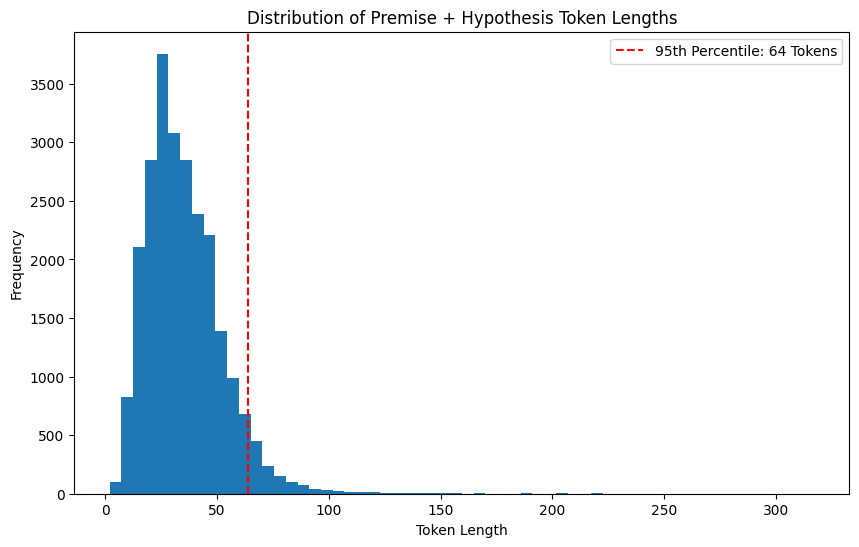

In [19]:
tokeniser = AutoTokenizer.from_pretrained(CONFIG.transformer_model)
token_lengths = df.apply(
    lambda row: len(tokeniser(row['premise'], row['hypothesis'])['input_ids']),
    axis=1
)

p95 = np.percentile(token_lengths, 95)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(token_lengths, bins=60)
ax.axvline(x=p95, color='red', linestyle='--', label=f'95th Percentile: {p95:.0f} Tokens')
ax.set_title('Distribution of Premise + Hypothesis Token Lengths')
ax.set_xlabel('Token Length')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()